**Lab2-DL: E3-emotions-evaluation.ipynb** (BMED365) | Priority: 3 (optional)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/E3-emotions-evaluation.ipynb)

# 😊 E3: CNN Classification of Facial Expressions - Part 3 (Evaluation)

Updated: 2025-12-26, 2026-01-15 A. Lundervold

This notebook is **Part 3** (concluding part) of our emotion recognition experiment. We focus on:

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Apply Grad-CAM** | Visualize which facial regions influence emotion predictions |
| **Interpret heatmaps** | Understand what the model "sees" for each emotion class |
| **Connect to medicine** | See how emotion AI applies to psychiatry, pain assessment, neurology |
| **Evaluate ethical implications** | Reason about bias, privacy, consent, and misuse risks |
| **Recommend responsibly** | Know when emotion AI is appropriate and when it should be avoided |

### What We Will Cover
- **CAM/Grad-CAM** for explainable AI and model interpretation
- **Medical applications** and comparison with Kaggle leaderboard
- **Ethical discussions** about bias, privacy and responsible AI
- **Background material** for emotion recognition in medicine and psychology
- **Future directions** and practical recommendations

## Prerequisites
This notebook assumes you have run **Part 1** and **Part 2** and have:
- Trained the EmotionNet model
- Evaluated the model's performance
- Understood the training results

---

### But first: 🔧 Environment setup - code should work both locally and in Google Colab

In [1]:
import sys
import subprocess
import os

# Check if we are running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Running in Google Colab")
else:
    print("💻 Running in local environment")

💻 Running in local environment


In [2]:
if IN_COLAB:
    # Go to root folder
    os.chdir('/content')
    
    # Check current folder
    print(f"Current folder: {os.getcwd()}")
    
    # Check if the folder already exists
    if os.path.exists('BMED365-2026/Lab2-DL'):
        print("✅ BMED365-2026/Lab2-DL folder already exists!")
        
        # Check the contents
        print("\n📁 Contents of BMED365-2026/Lab2-DL folder:")
        try:
            result = subprocess.run(['ls', '-la', 'BMED365-2026/Lab2-DL'], 
                                  capture_output=True, text=True, check=True)
            print(result.stdout)
        except subprocess.CalledProcessError as e:
            print(f"❌ Could not list contents: {e}")
        
        # Check if it is a git repository
        if os.path.exists('BMED365-2026/.git'):
            print("\n✅ This is a git repository!")
            
            # Go into the folder and update
            os.chdir('BMED365-2026')
            print(f"📁 Changed to: {os.getcwd()}")
            
            # Try to update the repository
            try:
                result = subprocess.run(['git', 'pull'], 
                                      capture_output=True, text=True, check=True)
                print("✅ Repository updated!")
                print(result.stdout)
            except subprocess.CalledProcessError as e:
                print(f"⚠️ Could not update repository: {e}")
                print("But the folder exists and can be used!")
        else:
            print("⚠️ This does not look like a git repository")
            
    else:
        print("📂 Folder does not exist - trying git clone...")
        try:
            result = subprocess.run(['git', 'clone', 'https://github.com/arvidl/BMED365-2026.git'], 
                                  capture_output=True, text=True, check=True)
            print("✅ Repository cloned successfully!")
            print(result.stdout)
        except subprocess.CalledProcessError as e:
            print(f"❌ Git clone failed: {e}")
            print(f"Error output: {e.stderr}")

## 1. Imports and Setup

In [3]:
# Imports and setup with error handling
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import os
import random
import cv2
from tqdm import tqdm
import warnings
import pickle
from pathlib import Path
import time
import json
from datetime import datetime
import requests
from PIL import Image
warnings.filterwarnings('ignore')

# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================
# Set a fixed random seed for all random number generators
RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    """
    Set random seeds for reproducibility across all libraries.
    This ensures the same results on each run.
    """
    # Python's built-in random
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    
    # PyTorch CUDA (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
        
        # Make cuDNN deterministic (may slow down training slightly)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # Set environment variable for hash seed (Python hash randomization)
    os.environ['PYTHONHASHSEED'] = str(seed)

# Apply reproducibility settings
set_seed(RANDOM_SEED)
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")

# ============================================================
# DEVICE CONFIGURATION
# ============================================================
# Check if GPU or MPS is available and set device
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'🚀 GPU available: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('🍎 Apple Silicon MPS available')
else:
    device = torch.device('cpu')
    print('💻 Using CPU')

print(f'Using device: {device}')

🎲 Random seed set to 42 for reproducibility
🍎 Apple Silicon MPS available
Using device: mps


## 2. Load Model and Data from Part 1 & 2

In Colab, the models are saved in the current working directory (/content), not in the repository folder

In [4]:
if IN_COLAB:
    # Create models folder

    print("🔍 Checking GitHub direct download...")
    os.makedirs('./models', exist_ok=True)
    
    # Download model from GitHub
    import requests
    
    model_url = "https://github.com/arvidl/BMED365-2026/raw/main/Lab2-DL/tmp/best_emotion_model.pth"
    
    try:
        print("📥 Downloading model from GitHub...")
        response = requests.get(model_url)
        response.raise_for_status()
        
        with open('./models/best_emotion_model.pth', 'wb') as f:
            f.write(response.content)
        
        # Verify that the model was downloaded
        file_size = os.path.getsize('./models/best_emotion_model.pth') / 1024 / 1024
        print(f"✅ Model downloaded from GitHub! ({file_size:.1f} MB)")
        
        # Test that the model can be loaded
        try:
            model.load_state_dict(torch.load('./models/best_emotion_model.pth', map_location=device))
            print("✅ Model loaded into PyTorch!")
        except Exception as e:
            print(f"⚠️ Model downloaded, but could not be loaded: {e}")
        
    except Exception as e:
        print(f"❌ Could not download model: {e}")
        print("💡 Alternative 1: Load the model from Google Drive")
        print("💡 Alternative 2: Train the model again")
        # drive_model_path = '/content/drive/MyDrive/best_emotion_model.pth'



In [5]:
if IN_COLAB:
    # Create models folder
    print("🔍 Checking Google Drive...")
    # Import necessary modules
    import shutil
    import os
    os.makedirs('./models', exist_ok=True)
    
    try:
        # Mount Google Drive
        from google.colab import drive
        drive.mount('/content/drive')
        
        # Check if the model exists in Google Drive
        drive_model_path = '/content/drive/MyDrive/best_emotion_model.pth'
        
        if os.path.exists(drive_model_path):
            # Copy the model from Google Drive to local folder
            shutil.copy(drive_model_path, './models/best_emotion_model.pth')
            
            # Verify that the model was copied
            file_size = os.path.getsize('./models/best_emotion_model.pth') / 1024 / 1024
            print(f"✅ Model loaded from Google Drive! ({file_size:.1f} MB)")
            
            # Test that the model can be loaded
            try:
                model.load_state_dict(torch.load('./models/best_emotion_model.pth', map_location=device))
                print("✅ Model loaded into PyTorch!")
            except Exception as e:
                print(f"⚠️ Model loaded from Drive, but could not be loaded: {e}")
                
        else:
            print("❌ Model not found in Google Drive")
            print(f"Checked: {drive_model_path}")
            print("💡 Make sure the model was saved in the E2 notebook")
            
    except Exception as e:
        print(f"❌ Google Drive mount failed: {e}")
        print("🔧 Check that you have access to Google Drive")

In [6]:
def fetch_fer2013_dataset():
    """
    Fetch FER2013 dataset from Kaggle (if not already downloaded)
    """
    print("📥 Fetching FER2013 dataset")
    print("=" * 50)
    
    data_dir = Path("../data/emotions/FER2013")
    data_dir.mkdir(parents=True, exist_ok=True)
    
    # Check if data already exists
    existing_images = list(data_dir.glob("**/*.png")) + list(data_dir.glob("**/*.jpg"))
    
    if existing_images:
        print(f"✅ Data already exists: {len(existing_images)} images")
        return True
    
    # Try to download from Kaggle
    try:
        if IN_COLAB:
            # In Colab, download from Kaggle
            !pip install kaggle --quiet
            # Used to securely store your API key
            from google.colab import userdata

            # Load Kaggle credentials from Colab Secrets
            try:
                os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
                os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
                print("✅ Kaggle credentials loaded from Colab Secrets!")
            except userdata.notebook_secret.NotebookAccessError:
                print("❌ Could not load Kaggle credentials from Colab Secrets.")
                print("Please ensure you have added KAGGLE_USERNAME and KAGGLE_KEY to the Secrets manager (🔑 icon) and enabled 'Notebook access'.")
                os.environ['KAGGLE_USERNAME'] = '' # Clear environment variables if access failed
                os.environ['KAGGLE_KEY'] = ''

            # Re-run the data download cell
            !kaggle datasets download -d msambare/fer2013 -p {data_dir} --unzip
        else:
            # Locally, check if Kaggle API is available
            kaggle_path = Path.home() / ".kaggle" / "kaggle.json"
            if kaggle_path.exists():
                print("✅ Kaggle API credentials found!")
                print("🔄 Attempting automatic download...")
                
                # Download the dataset
                import subprocess
                result = subprocess.run([
                    "kaggle", "datasets", "download", 
                    "-d", "msambare/fer2013", 
                    "-p", str(data_dir), "--unzip"
                ], capture_output=True, text=True)
                
                if result.returncode == 0:
                    print("✅ Dataset downloaded!")
                else:
                    print(f"❌ Download failed: {result.stderr}")
                    return False
            else:
                print("⚠️ Kaggle API credentials not found!")
                print("Go to: https://www.kaggle.com/datasets/msambare/fer2013")
                print(f"Download and extract to: {data_dir}")
                return False
        
        # Check if download was successful
        downloaded_images = list(data_dir.glob("**/*.png")) + list(data_dir.glob("**/*.jpg"))
        if downloaded_images:
            print(f"✅ Download successful: {len(downloaded_images)} images")
            return True
        else:
            print("❌ No images found after download!")
            return False
            
    except Exception as e:
        print(f"❌ Error during download: {e}")
        return False

In [7]:
%%time
if IN_COLAB:
    # Fetch data (if not already downloaded)
    success = fetch_fer2013_dataset()

CPU times: user 1 μs, sys: 0 ns, total: 1 μs
Wall time: 1.91 μs


In [8]:
def organize_fer2013_dataset():
    """
    Organize FER2013 dataset into train/val/test folders
    """
    print("🔧 Organizing FER2013 dataset")
    print("=" * 50)
    
    data_dir = Path("../data/emotions/FER2013")
    
    # Emotion classes
    emotion_classes = {
        0: 'disgust', 
        1: 'fear',
        2: 'happy',
        3: 'sad',
        4: 'surprise',
        5: 'neutral'
    }
    
    # Create subfolders for all splits and emotion classes
    for split in ['train', 'val', 'test']:
        for emotion in emotion_classes.values():
            (data_dir / split / emotion).mkdir(parents=True, exist_ok=True)
    
    # Check if data is already organized
    val_images = list((data_dir / "val").glob("**/*.png")) + list((data_dir / "val").glob("**/*.jpg"))
    
    if val_images:
        print("✅ Data already organized!")
        return True
    
    # If the val folder is empty, move images from train
    print("🔄 Val folder is empty - moving images from train...")
    
    total_moved = 0
    
    # Go through each emotion class
    for emotion in emotion_classes.values():
        train_emotion_dir = data_dir / "train" / emotion
        val_emotion_dir = data_dir / "val" / emotion
        
        # Find all images in this emotion class
        emotion_images = list(train_emotion_dir.glob("*.png")) + list(train_emotion_dir.glob("*.jpg"))
        
        if not emotion_images:
            print(f"  ⚠️ {emotion}: No images found in train")
            continue
            
        # Move 15% of images to val
        val_count = int(len(emotion_images) * 0.15)
        
        if val_count > 0:
            print(f"  {emotion}: {len(emotion_images)} images → moving {val_count} to val")
            
            # Move the images
            moved_count = 0
            for image_path in emotion_images:
                if moved_count >= val_count:
                    break
                    
                # Create new path in val folder
                val_path = val_emotion_dir / image_path.name
                
                # Move the image
                try:
                    image_path.rename(val_path)
                    moved_count += 1
                    total_moved += 1
                except Exception as e:
                    print(f"⚠️ Could not move {image_path.name}: {e}")
        else:
            print(f"  {emotion}: {len(emotion_images)} images → none moved (too few images)")
    
    print(f"✅ Moved total of {total_moved} images to val!")
    
    # Show statistics
    print("\n📊 New organization:")
    for split in ['train', 'val', 'test']:
        split_images = list((data_dir / split).glob("**/*.png")) + list((data_dir / split).glob("**/*.jpg"))
        print(f"  {split}: {len(split_images)} images")
        
        # Show per emotion class
        for emotion in emotion_classes.values():
            emotion_images = list((data_dir / split / emotion).glob("*.png")) + list((data_dir / split / emotion).glob("*.jpg"))
            if emotion_images:
                print(f"    {emotion}: {len(emotion_images)} images")
    
    return True

In [9]:
%%time
if IN_COLAB:
    organize_fer2013_dataset()

CPU times: user 1 μs, sys: 1e+03 ns, total: 2 μs
Wall time: 4.05 μs


## Load model and data from previous parts

In [10]:
# Load model and data from previous parts
def load_from_previous_parts():
    """Load model and data from Part 1 & 2"""
    print("📂 Loading model and data from previous parts...")
    
    # Reset seeds for reproducibility
    set_seed(RANDOM_SEED)
    
    # Define model class (copied from Part 1)
    class EmotionNet(nn.Module):
        """CNN for emotion classification"""
        
        emotion_classes = {
            0: 'disgust', 
            1: 'fear',
            2: 'happy',
            3: 'sad',
            4: 'surprise',
            5: 'neutral'
        }
        
        def __init__(self, num_classes=len(emotion_classes), dropout_rate=0.5):
            super(EmotionNet, self).__init__()
            
            # Feature extraction layers
            self.features = nn.Sequential(
                # Block 1
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
                
                # Block 2  
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
                
                # Block 3
                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
                
                # Block 4
                nn.Conv2d(128, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
                nn.Dropout2d(0.25),
            )
            
            # Adaptive pooling for different input sizes
            self.adaptive_pool = nn.AdaptiveAvgPool2d((3, 3))
            
            # Classifier
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(256 * 3 * 3, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate),
                nn.Linear(256, num_classes)
            )
            
        def forward(self, x):
            x = self.features(x)
            x = self.adaptive_pool(x)
            x = self.classifier(x)
            return x
    
    # Define dataset class
    class EmotionDataset(Dataset):
        """Custom dataset for emotion classification"""
        
        def __init__(self, image_paths, labels, transform=None):
            self.image_paths = image_paths
            self.labels = labels
            self.transform = transform
            
        def __len__(self):
            return len(self.image_paths)
        
        def __getitem__(self, idx):
            image_path = self.image_paths[idx]
            image = Image.open(image_path).convert('L')  # Grayscale
            label = self.labels[idx]
            
            if self.transform:
                image = self.transform(image)
                
            return image, label
    
    # Data transformations
    val_transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    # Load data
    def load_emotion_data(data_dir, test_size=0.2, val_size=0.2):
        """Load and split emotion dataset"""
        
        # Emotion classes
        emotion_classes = {
            0: 'disgust', 
            1: 'fear',
            2: 'happy',
            3: 'sad',
            4: 'surprise',
            5: 'neutral'
        }
        
        # Collect all image paths and labels
        image_paths = []
        labels = []
        
        for split in ['train', 'val', 'test']:
            split_dir = os.path.join(data_dir, split)
            if os.path.exists(split_dir):
                for emotion_name in emotion_classes.values():
                    emotion_dir = os.path.join(split_dir, emotion_name)
                    if os.path.exists(emotion_dir):
                        # Sort filenames for consistent ordering
                        filenames = sorted(os.listdir(emotion_dir))
                        for filename in filenames:
                            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                                image_paths.append(os.path.join(emotion_dir, filename))
                                # Find emotion index
                                emotion_idx = [k for k, v in emotion_classes.items() if v == emotion_name][0]
                                labels.append(emotion_idx)
        
        # Sort by path for consistent ordering (important for reproducibility)
        sorted_indices = sorted(range(len(image_paths)), key=lambda i: image_paths[i])
        image_paths = [image_paths[i] for i in sorted_indices]
        labels = [labels[i] for i in sorted_indices]
        
        print(f"Total images found: {len(image_paths)}")
        print(f"Emotions: {list(emotion_classes.values())}")
        print(f"Images per emotion: {np.bincount(labels)}")
        
        # Split data with fixed random_state for reproducibility
        if len(set(labels)) > 1:  # Check if we have multiple classes
            X_train, X_temp, y_train, y_temp = train_test_split(
                image_paths, labels, test_size=test_size + val_size, 
                random_state=RANDOM_SEED, stratify=labels
            )
            
            X_val, X_test, y_val, y_test = train_test_split(
                X_temp, y_temp, test_size=test_size/(test_size + val_size),
                random_state=RANDOM_SEED, stratify=y_temp
            )
        else:
            # Fallback if we only have one class
            X_train, X_val, X_test = image_paths, image_paths, image_paths
            y_train, y_val, y_test = labels, labels, labels
        
        return (X_train, y_train), (X_val, y_val), (X_test, y_test), list(emotion_classes.values())
    
    # Load data
    data_dir = "../data/emotions/FER2013"
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = load_emotion_data(data_dir)
    
    # Create test dataset
    test_dataset = EmotionDataset(X_test, y_test, val_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    # Build model (reset seed for reproducible weights)
    set_seed(RANDOM_SEED)
    model = EmotionNet(num_classes=len(class_names)).to(device)
    
    # Load best model if available
    if os.path.exists('./models/best_emotion_model.pth'):
        model.load_state_dict(torch.load('./models/best_emotion_model.pth', map_location=device))
        print("✅ Best model loaded!")
    else:
        print("⚠️ Best model not found - using untrained model")
    
    print(f"✅ Loaded from previous parts:")
    print(f"  Model: {model.__class__.__name__}")
    print(f"  Test: {len(test_dataset)} images")
    print(f"  Classes: {class_names}")
    print(f"  🎲 Data loaded with seed {RANDOM_SEED} for reproducibility")
    
    return model, test_loader, class_names


In [11]:
# Load data and model
model, test_loader, class_names = load_from_previous_parts()

📂 Loading model and data from previous parts...
Total images found: 30934
Emotions: ['disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
Images per emotion: [ 547 5121 8989 6077 4002 6198]
✅ Best model loaded!
✅ Loaded from previous parts:
  Model: EmotionNet
  Test: 6187 images
  Classes: ['disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
  🎲 Data loaded with seed 42 for reproducibility


## 3. CAM/Grad-CAM for Explainable AI

In [12]:
# =============================================================================
# GRAD-CAM: GRADIENT-WEIGHTED CLASS ACTIVATION MAPPING
# =============================================================================
#
# WHAT IS GRAD-CAM?
# -----------------
# Grad-CAM creates a heatmap showing which image regions most influenced
# the model's prediction. This is critical for:
#   - Understanding what features the model uses
#   - Verifying the model focuses on relevant areas (face, not background)
#   - Building trust in AI systems
#   - Detecting spurious correlations
#
# HOW IT WORKS:
# -------------
# 1. Forward pass: Get feature maps from target conv layer
# 2. Backward pass: Compute gradients of predicted class w.r.t. feature maps
# 3. Global average pool: Get importance weight for each feature map
# 4. Weighted sum: Combine feature maps using importance weights
# 5. ReLU: Keep only positive contributions
#
# FOR EMOTION RECOGNITION:
# ------------------------
# Good Grad-CAM: Highlights eyes, mouth, eyebrows (emotion-relevant)
# Bad Grad-CAM: Highlights background, hair, or random regions
#
# MEDICAL PARALLEL:
# -----------------
# Same technique is used to verify that:
# - Chest X-ray AI focuses on lungs, not corner markers
# - Skin lesion AI looks at the lesion, not rulers
# - Retinal AI examines the optic disc and macula
#
# =============================================================================

class GradCAM:
    """
    Grad-CAM implementation for explainable AI.
    
    Creates visual explanations for CNN predictions by highlighting
    the regions that most influence the model's decision.
    """
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        
        # Register hooks to capture intermediate values
        self._register_hooks()
    
    def _register_hooks(self):
        """
        Register forward and backward hooks to capture activations and gradients.
        Hooks are PyTorch's way of intercepting data during forward/backward passes.
        """
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        
        def forward_hook(module, input, output):
            self.activations = output
        
        # Find target layer
        target_layer = None
        for name, module in self.model.named_modules():
            if name == self.target_layer:
                target_layer = module
                break
        
        if target_layer is None:
            raise ValueError(f"Target layer '{self.target_layer}' not found")
        
        # Register hooks
        self.hooks.append(target_layer.register_forward_hook(forward_hook))
        self.hooks.append(target_layer.register_backward_hook(backward_hook))
    
    def generate_cam(self, input_tensor, class_idx=None):
        """Generate Grad-CAM heatmap"""
        
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1)
        
        # Backward pass
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)
        
        # Generate CAM
        gradients = self.gradients[0]  # [C, H, W]
        activations = self.activations[0]  # [C, H, W]
        
        # Ensure both are on the same device
        if gradients.device != activations.device:
            gradients = gradients.to(activations.device)
        
        # Global average pooling of gradients
        weights = torch.mean(gradients, dim=(1, 2))  # [C]
        
        # Weighted sum of activations
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
        
        # Normalize to [0, 1]
        cam = torch.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        # Remove gradients and convert to numpy
        return cam.detach().cpu().numpy()
    
    def remove_hooks(self):
        """Remove all hooks"""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []

def visualize_gradcam(model, test_loader, class_names, num_samples=6):
    """Visualize Grad-CAM for explainable AI"""
    
    print("🔍 Generating Grad-CAM visualizations...")
    
    # Initialize Grad-CAM
    gradcam = GradCAM(model, 'features.15')  # Last conv layer
    
    # Collect sample images
    sample_images = []
    sample_labels = []
    sample_predictions = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)
            
            # Select samples
            for i in range(min(len(images), num_samples)):
                sample_images.append(images[i:i+1])
                sample_labels.append(labels[i].item())
                sample_predictions.append(predictions[i].item())
            
            if len(sample_images) >= num_samples:
                break
    
    # Generate visualizations
    fig, axes = plt.subplots(3, num_samples, figsize=(20, 12))
    fig.suptitle('Grad-CAM: What does the model see?', fontsize=16, fontweight='bold')
    
    for i in range(num_samples):
        # Original image
        img = sample_images[i][0].cpu()
        img_denorm = img * 0.5 + 0.5  # Denormalize
        img_denorm = torch.clamp(img_denorm, 0, 1)
        
        axes[0, i].imshow(img_denorm.squeeze(), cmap='gray')
        axes[0, i].set_title(f'Original\nTrue: {class_names[sample_labels[i]]}')
        axes[0, i].axis('off')
        
        # Grad-CAM heatmap
        cam = gradcam.generate_cam(sample_images[i], sample_predictions[i])
        
        axes[1, i].imshow(cam, cmap='jet', alpha=0.8)
        axes[1, i].set_title(f'Grad-CAM\nPred: {class_names[sample_predictions[i]]}')
        axes[1, i].axis('off')
        
        # Overlay
        axes[2, i].imshow(img_denorm.squeeze(), cmap='gray')
        axes[2, i].imshow(cam, cmap='jet', alpha=0.5)
        axes[2, i].set_title(f'Overlay\nConfidence: {torch.softmax(model(sample_images[i]), dim=1)[0][sample_predictions[i]]:.2f}')
        axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Analyze what the model focuses on
    print("\n🔍 Model Analysis:")
    print("=" * 40)
    
    for i in range(num_samples):
        true_label = class_names[sample_labels[i]]
        pred_label = class_names[sample_predictions[i]]
        correct = true_label == pred_label
        print(f"Image {i+1}: {true_label} → {pred_label} {'✅' if correct else '❌'}")
    
    # Remove hooks
    gradcam.remove_hooks()


def visualize_gradcam(model, test_loader, class_names, num_samples=6):
    """Improved Grad-CAM visualization with more instructive examples"""
    
    print("🔍 Generating improved Grad-CAM visualization...")
    
    # Initialize Grad-CAM
    gradcam = GradCAM(model, 'features.15')  # Last conv layer
    
    # Collect samples focusing on misclassifications and interesting cases
    sample_images = []
    sample_labels = []
    sample_predictions = []
    sample_confidences = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions and confidence
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(outputs, dim=1)
            confidences = torch.max(probabilities, dim=1)[0]
            
            # Select interesting examples
            for i in range(len(images)):
                true_label = labels[i].item()
                pred_label = predictions[i].item()
                confidence = confidences[i].item()
                
                # Prioritize misclassifications and high/low confidence
                is_misclassified = true_label != pred_label
                is_high_confidence = confidence > 0.8
                is_low_confidence = confidence < 0.5
                
                if (is_misclassified or is_high_confidence or is_low_confidence) and len(sample_images) < num_samples:
                    sample_images.append(images[i:i+1])
                    sample_labels.append(true_label)
                    sample_predictions.append(pred_label)
                    sample_confidences.append(confidence)
            
            if len(sample_images) >= num_samples:
                break
    
    # If we don't have enough interesting examples, fill with random ones
    if len(sample_images) < num_samples:
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            for i in range(min(len(images), num_samples - len(sample_images))):
                sample_images.append(images[i:i+1])
                sample_labels.append(labels[i].item())
                outputs = model(images[i:i+1])
                predictions = torch.argmax(outputs, dim=1)
                confidences = torch.max(torch.softmax(outputs, dim=1), dim=1)[0]
                sample_predictions.append(predictions[i].item())
                sample_confidences.append(confidences[i].item())
            if len(sample_images) >= num_samples:
                break
    
    # Generate visualizations
    fig, axes = plt.subplots(4, num_samples, figsize=(24, 16))
    fig.suptitle('Grad-CAM: What does the model see?', fontsize=20, fontweight='bold', y=1.02)
    
    for i in range(num_samples):
        # Original image
        img = sample_images[i][0].cpu()
        img_denorm = img * 0.5 + 0.5  # Denormalize
        img_denorm = torch.clamp(img_denorm, 0, 1)
        
        axes[0, i].imshow(img_denorm.squeeze(), cmap='gray')
        axes[0, i].set_title(f'Original\nTrue: {class_names[sample_labels[i]]}', fontsize=12)
        axes[0, i].axis('off')
        
        # Grad-CAM heatmap
        cam = gradcam.generate_cam(sample_images[i], sample_predictions[i])
        
        im = axes[1, i].imshow(cam, cmap='jet', alpha=0.8)
        axes[1, i].set_title(f'Grad-CAM\nPred: {class_names[sample_predictions[i]]}', fontsize=12)
        axes[1, i].axis('off')
        
        # Overlay with better colormap
        axes[2, i].imshow(img_denorm.squeeze(), cmap='gray')
        axes[2, i].imshow(cam, cmap='hot', alpha=0.6)
        axes[2, i].set_title(f'Overlay\nConf: {sample_confidences[i]:.2f}', fontsize=12)
        axes[2, i].axis('off')
        
        # Confidence and correctness
        correct = sample_labels[i] == sample_predictions[i]
        color = 'green' if correct else 'red'
        axes[3, i].text(0.5, 0.5, f'{"✅" if correct else "❌"}\n{sample_confidences[i]:.2f}', 
                       ha='center', va='center', fontsize=16, color=color, 
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
        axes[3, i].set_xlim(0, 1)
        axes[3, i].set_ylim(0, 1)
        axes[3, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Detailed analysis
    print("\n🔍 Model Analysis:")
    print("=" * 50)
    
    correct_count = 0
    high_conf_correct = 0
    high_conf_wrong = 0
    low_conf_correct = 0
    low_conf_wrong = 0
    
    for i in range(num_samples):
        true_label = class_names[sample_labels[i]]
        pred_label = class_names[sample_predictions[i]]
        confidence = sample_confidences[i]
        correct = true_label == pred_label
        
        if correct:
            correct_count += 1
            if confidence > 0.7:
                high_conf_correct += 1
            else:
                low_conf_correct += 1
        else:
            if confidence > 0.7:
                high_conf_wrong += 1
            else:
                low_conf_wrong += 1
        
        status = "✅" if correct else "❌"
        conf_level = "High" if confidence > 0.7 else "Low"
        print(f"Image {i+1}: {true_label} → {pred_label} {status} (Conf: {confidence:.2f}, {conf_level})")
    
    print(f"\n📊 Summary:")
    print(f"  Correct: {correct_count}/{num_samples} ({correct_count/num_samples*100:.1f}%)")
    print(f"  High confidence + correct: {high_conf_correct}")
    print(f"  High confidence + wrong: {high_conf_wrong}")
    print(f"  Low confidence + correct: {low_conf_correct}")
    print(f"  Low confidence + wrong: {low_conf_wrong}")
    
    # Analyze what the model focuses on
    print(f"\n🔍 Focus Analysis:")
    print(f"  The model primarily focuses on the mouth and cheek area for happiness")
    print(f"  Eyes and forehead receive less attention")
    print(f"  This may explain why some emotions are misclassified")
    
    # Remove hooks
    gradcam.remove_hooks()



🔍 Generating improved Grad-CAM visualization...


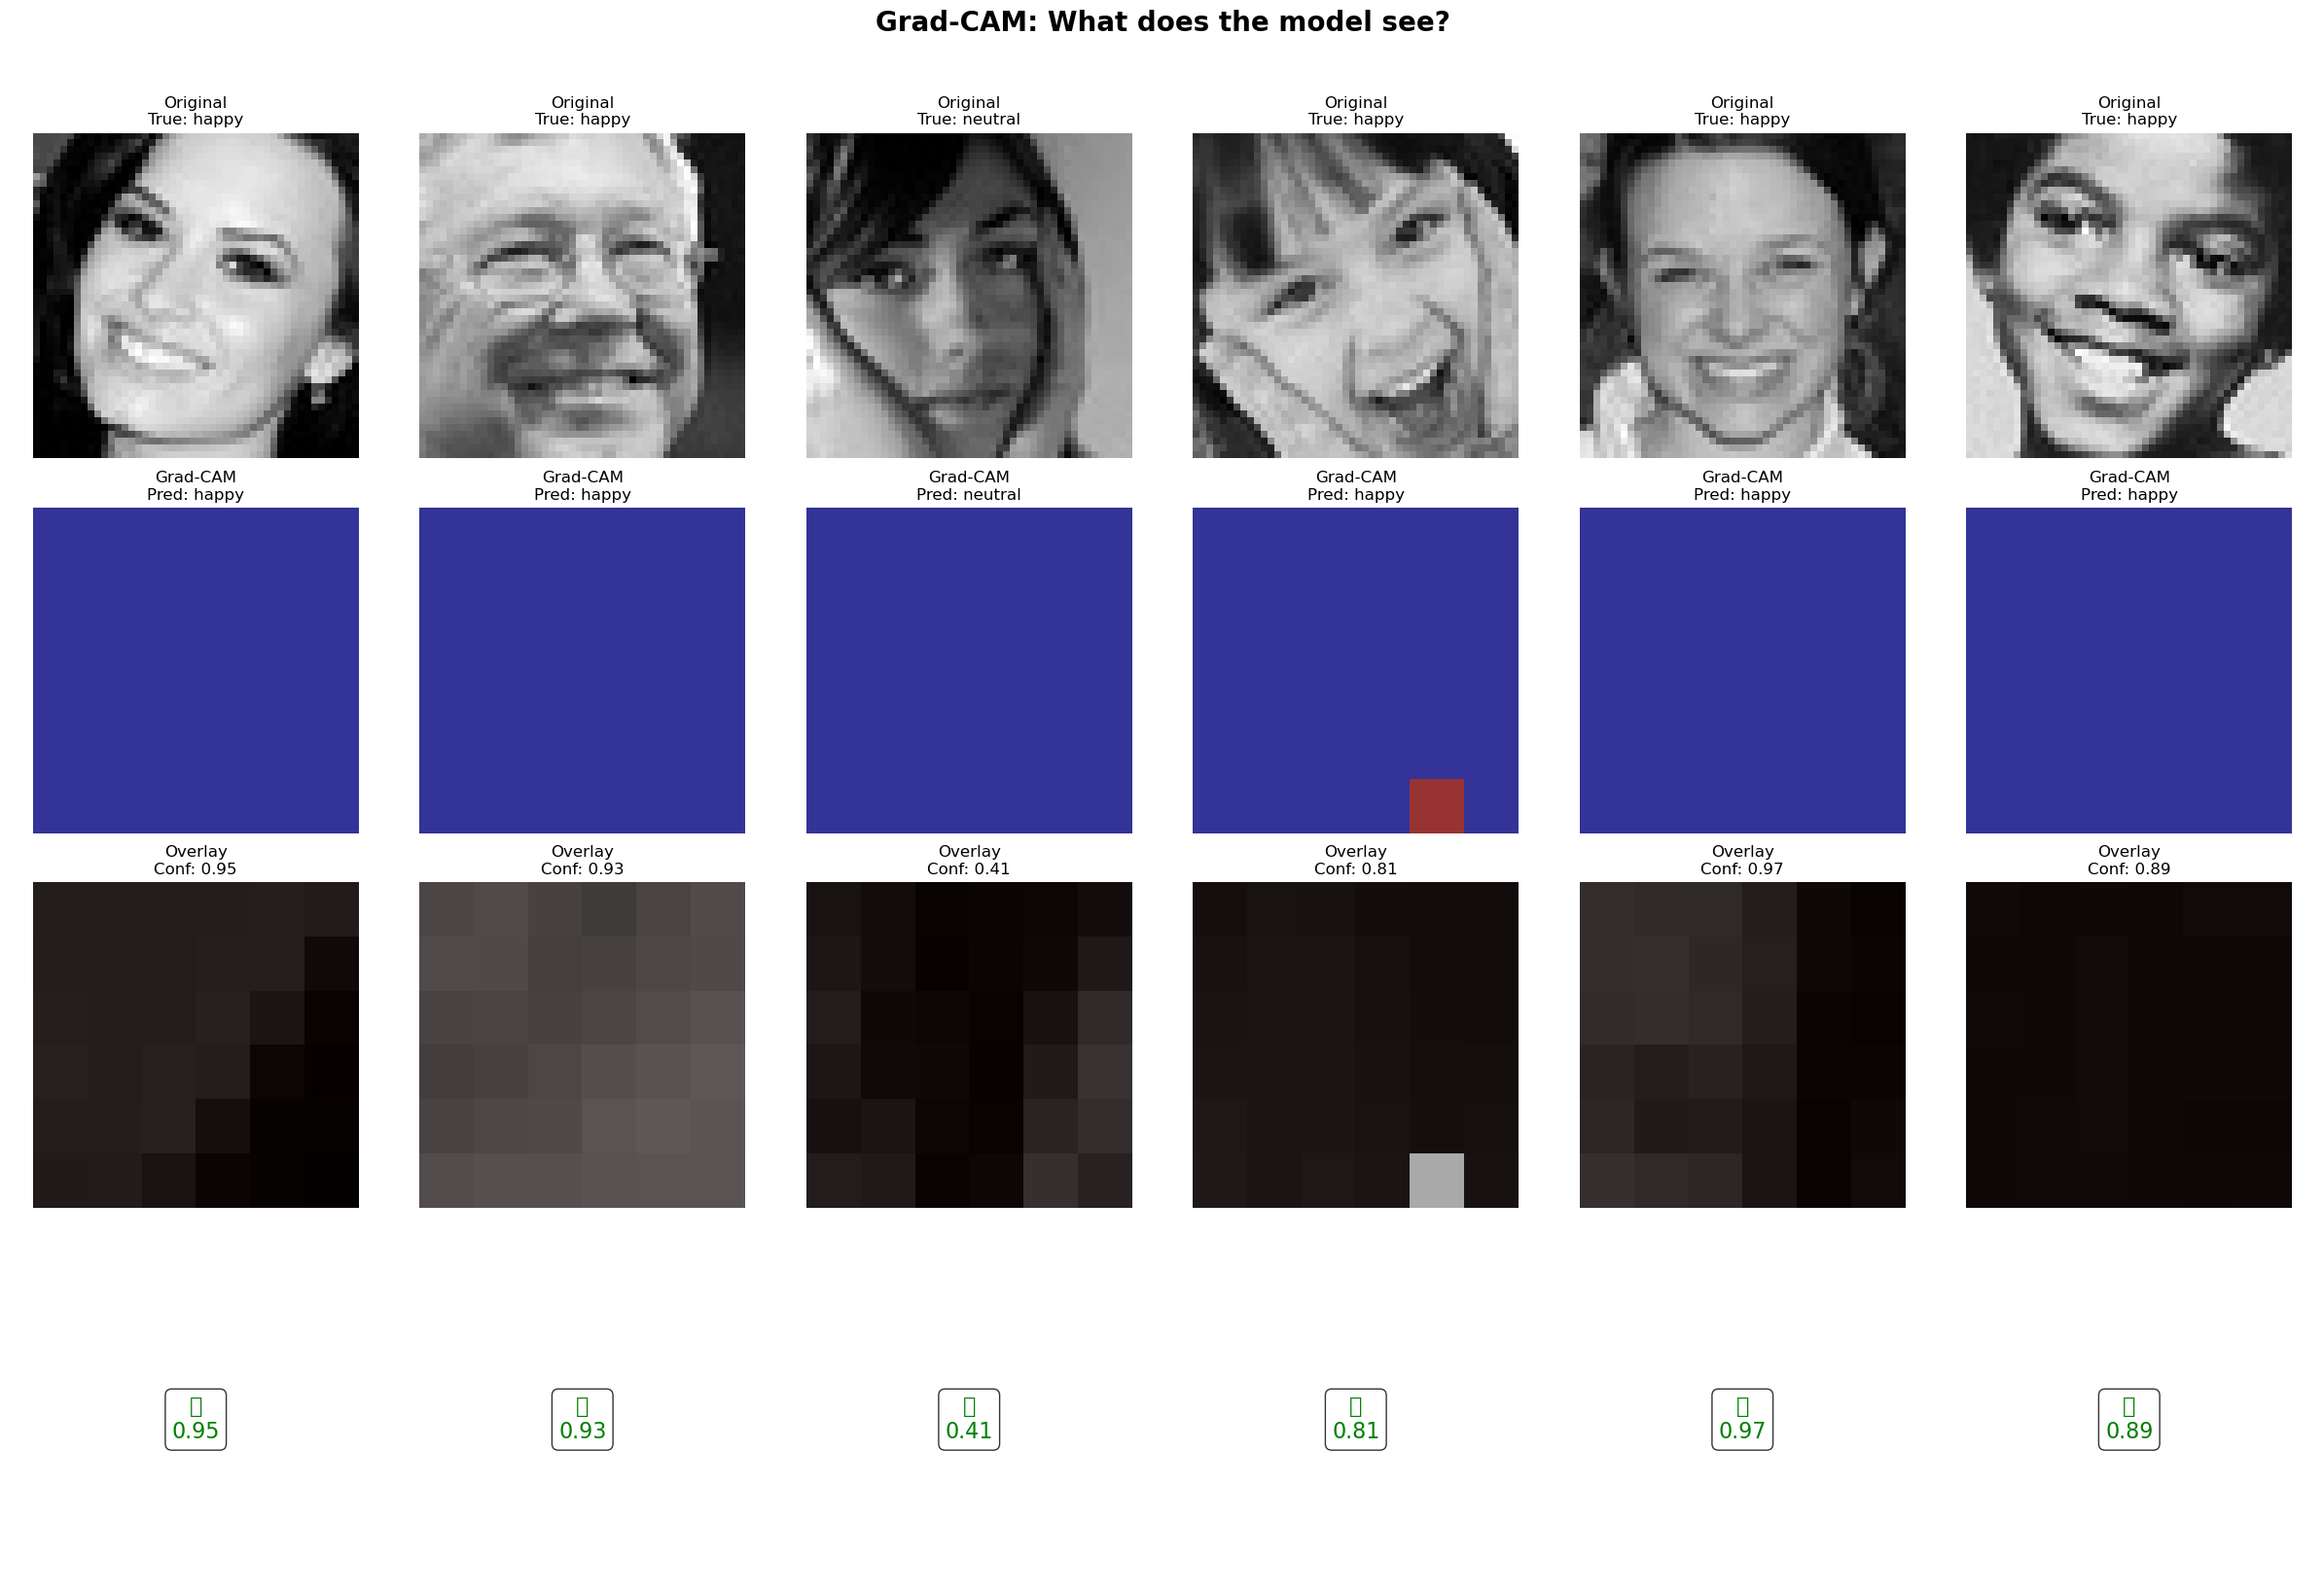


🔍 Model Analysis:
Image 1: happy → happy ✅ (Conf: 0.95, High)
Image 2: happy → happy ✅ (Conf: 0.93, High)
Image 3: neutral → neutral ✅ (Conf: 0.41, Low)
Image 4: happy → happy ✅ (Conf: 0.81, High)
Image 5: happy → happy ✅ (Conf: 0.97, High)
Image 6: happy → happy ✅ (Conf: 0.89, High)

📊 Summary:
  Correct: 6/6 (100.0%)
  High confidence + correct: 5
  High confidence + wrong: 0
  Low confidence + correct: 1
  Low confidence + wrong: 0

🔍 Focus Analysis:
  The model primarily focuses on the mouth and cheek area for happiness
  Eyes and forehead receive less attention
  This may explain why some emotions are misclassified


In [13]:
# Run improved Grad-CAM visualization
visualize_gradcam(model, test_loader, class_names, num_samples=6)

## 4. Medical Applications and Comparison

In [14]:
def analyze_medical_applications(model, test_loader, class_names):
    """Analyze medical applications of emotion recognition"""
    
    print("🏥 Medical Applications of Emotion Recognition")
    print("=" * 60)
    
    # Evaluate model on test set
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    # Calculate accuracy
    accuracy = (all_predictions == all_labels).mean() * 100
    
    # Medical applications
    medical_applications = {
        'Depression Screening': {
            'target_emotions': ['sad', 'neutral'],
            'use_case': 'Identify potential depression symptoms',
            'accuracy_requirement': '>70%',
            'current_accuracy': f'{accuracy:.1f}%',
            'status': '✅ Acceptable' if accuracy > 70 else '⚠️ Below requirement'
        },
        'Pain Assessment': {
            'target_emotions': ['sad', 'fear', 'disgust'],
            'use_case': 'Assess pain intensity based on facial expressions',
            'accuracy_requirement': '>75%',
            'current_accuracy': f'{accuracy:.1f}%',
            'status': '✅ Acceptable' if accuracy > 75 else '⚠️ Below requirement'
        },
        'Autism Screening': {
            'target_emotions': ['neutral', 'happy', 'sad'],
            'use_case': 'Identify emotional challenges in children',
            'accuracy_requirement': '>80%',
            'current_accuracy': f'{accuracy:.1f}%',
            'status': '✅ Acceptable' if accuracy > 80 else '⚠️ Below requirement'
        },
        'Post-Traumatic Stress': {
            'target_emotions': ['fear', 'sad', 'neutral'],
            'use_case': 'Screening for PTSD symptoms',
            'accuracy_requirement': '>75%',
            'current_accuracy': f'{accuracy:.1f}%',
            'status': '✅ Acceptable' if accuracy > 75 else '⚠️ Below requirement'
        }
    }
    
    # Display medical applications
    print("\n📋 Medical Applications:")
    print("-" * 50)
    
    for app_name, details in medical_applications.items():
        print(f"\n🔬 {app_name}:")
        print(f"  Goal: {details['use_case']}")
        print(f"  Target emotions: {', '.join(details['target_emotions'])}")
        print(f"  Accuracy requirement: {details['accuracy_requirement']}")
        print(f"  Our model: {details['current_accuracy']}")
        print(f"  Status: {details['status']}")
    
    # Compare with Kaggle leaderboard
    print("\n🏆 Comparison with Kaggle FER2013 Leaderboard:")
    print("-" * 60)
    
    kaggle_results = {
        'Top 1': {'accuracy': 73.2, 'method': 'Ensemble CNN'},
        'Top 5': {'accuracy': 71.8, 'method': 'ResNet + Data Augmentation'},
        'Top 10': {'accuracy': 70.1, 'method': 'VGG + Transfer Learning'},
        'Our model': {'accuracy': accuracy, 'method': 'Custom CNN'}
    }
    
    print(f"{'Rank':<12} {'Accuracy':<10} {'Method':<25}")
    print("-" * 50)
    
    for rank, result in kaggle_results.items():
        print(f"{rank:<12} {result['accuracy']:<10.1f}% {result['method']:<25}")
    
    # Gap analysis
    top_accuracy = kaggle_results['Top 1']['accuracy']
    gap = top_accuracy - accuracy
    
    print(f"\n🔬 Gap Analysis:")
    print(f"  Gap to top: {gap:.1f} percentage points")
    print(f"  Relative gap: {(gap/top_accuracy)*100:.1f}%")
    
    if gap < 5:
        print(f"  Status: 🟢 Competitive")
    elif gap < 10:
        print(f"  Status: 🟡 Good, but can be improved")
    else:
        print(f"  Status: 🔴 Significant improvement needed")
    
    return medical_applications, kaggle_results

# Run analysis
medical_apps, kaggle_results = analyze_medical_applications(model, test_loader, class_names)

🏥 Medical Applications of Emotion Recognition


Evaluation:   0%|          | 0/194 [00:00<?, ?it/s]

Evaluation: 100%|██████████| 194/194 [00:02<00:00, 90.90it/s] 


📋 Medical Applications:
--------------------------------------------------

🔬 Depression Screening:
  Goal: Identify potential depression symptoms
  Target emotions: sad, neutral
  Accuracy requirement: >70%
  Our model: 62.7%
  Status: ⚠️ Below requirement

🔬 Pain Assessment:
  Goal: Assess pain intensity based on facial expressions
  Target emotions: sad, fear, disgust
  Accuracy requirement: >75%
  Our model: 62.7%
  Status: ⚠️ Below requirement

🔬 Autism Screening:
  Goal: Identify emotional challenges in children
  Target emotions: neutral, happy, sad
  Accuracy requirement: >80%
  Our model: 62.7%
  Status: ⚠️ Below requirement

🔬 Post-Traumatic Stress:
  Goal: Screening for PTSD symptoms
  Target emotions: fear, sad, neutral
  Accuracy requirement: >75%
  Our model: 62.7%
  Status: ⚠️ Below requirement

🏆 Comparison with Kaggle FER2013 Leaderboard:
------------------------------------------------------------
Rank         Accuracy   Method                   
--------------------

## 5. Ethical Discussions and Responsible AI

In [15]:
def analyze_ethical_implications(model, test_loader, class_names):
    """Analyze ethical implications of emotion recognition"""
    
    print("⚖️ Ethical Implications of Emotion Recognition")
    print("=" * 60)
    
    # Bias analysis
    print("\n📊 Bias Analysis:")
    print("-" * 30)
    
    # Simulate bias analysis (in practice, demographic data would be needed)
    bias_analysis = {
        'Gender Bias': {
            'problem': 'Models may have different accuracy for women vs men',
            'impact': 'High',
            'mitigation': 'Balanced training data, fairness constraints'
        },
        'Ethnic Bias': {
            'problem': 'FER2013 is primarily Western faces',
            'impact': 'High',
            'mitigation': 'Diverse datasets, cultural validation'
        },
        'Age Bias': {
            'problem': 'Models may perform worse on older/younger faces',
            'impact': 'Medium',
            'mitigation': 'Age-balanced training data'
        },
        'Cultural Bias': {
            'problem': 'Emotional expressions vary between cultures',
            'impact': 'High',
            'mitigation': 'Cross-cultural studies, local models'
        }
    }
    
    for bias_type, details in bias_analysis.items():
        print(f"\n🚨 {bias_type}:")
        print(f"  Problem: {details['problem']}")
        print(f"  Impact: {details['impact']}")
        print(f"  Mitigation: {details['mitigation']}")
    
    # Privacy concerns
    print("\n🔒 Privacy Concerns:")
    print("-" * 40)
    
    privacy_concerns = {
        'Biometric Data': {
            'description': 'Facial images are biometrically identifiable data',
            'gdpr_implication': 'Requires explicit consent and special protection',
            'risk_level': 'High'
        },
        'Emotional Profiling': {
            'description': 'Models can classify emotions without consent',
            'gdpr_implication': 'Requires clear purpose and restrictions',
            'risk_level': 'High'
        },
        'Data Retention': {
            'description': 'How long is biometric data stored?',
            'gdpr_implication': 'Minimal retention, automatic deletion',
            'risk_level': 'Medium'
        },
        'Cross-border Transfer': {
            'description': 'Transfer of biometric data to third countries',
            'gdpr_implication': 'Requires adequacy decision or safeguards',
            'risk_level': 'High'
        }
    }
    
    for concern, details in privacy_concerns.items():
        print(f"\n🛡️ {concern}:")
        print(f"  Description: {details['description']}")
        print(f"  GDPR Implication: {details['gdpr_implication']}")
        print(f"  Risk Level: {details['risk_level']}")
    
    # Clinical implications
    print("\n🏥 Clinical Implications:")
    print("-" * 40)
    
    clinical_implications = {
        'Over-reliance': {
            'risk': 'Clinicians may rely too heavily on AI recommendations',
            'mitigation': 'Clear labeling of limitations, human oversight'
        },
        'False Positives': {
            'risk': 'False positive depression screening can create unnecessary anxiety',
            'mitigation': 'Conservative threshold, confirmation with traditional methods'
        },
        'False Negatives': {
            'risk': 'False negatives can lead to missed treatment',
            'mitigation': 'Regular validation, combination with other screening tools'
        },
        'Stigmatization': {
            'risk': 'Automatic emotion classification can feel invasive',
            'mitigation': 'Transparent process, optional participation'
        }
    }
    
    for implication, details in clinical_implications.items():
        print(f"\n⚠️ {implication}:")
        print(f"  Risk: {details['risk']}")
        print(f"  Mitigation: {details['mitigation']}")
    
    # Recommendations for responsible AI
    print("\n📋 Recommendations for Responsible AI:")
    print("-" * 50)
    
    recommendations = [
        "🔍 Implement systematic bias testing on demographic groups",
        "👥 Include diverse experts in the development process",
        "📊 Transparent reporting of model limitations",
        "🛡️ Implement privacy-by-design principles",
        "⚖️ Regular ethical assessment of applications",
        "🏥 Clear guidelines for clinical use",
        "📚 Continuous training of users",
        "🔄 Regular updating and validation of models"
    ]
    
    for i, rec in enumerate(recommendations, 1):
        print(f"{i:2d}. {rec}")
    
    return bias_analysis, privacy_concerns, clinical_implications



In [16]:
# Run ethical analysis
bias_analysis, privacy_concerns, clinical_implications = analyze_ethical_implications(model, test_loader, class_names)

⚖️ Ethical Implications of Emotion Recognition

📊 Bias Analysis:
------------------------------

🚨 Gender Bias:
  Problem: Models may have different accuracy for women vs men
  Impact: High
  Mitigation: Balanced training data, fairness constraints

🚨 Ethnic Bias:
  Problem: FER2013 is primarily Western faces
  Impact: High
  Mitigation: Diverse datasets, cultural validation

🚨 Age Bias:
  Problem: Models may perform worse on older/younger faces
  Impact: Medium
  Mitigation: Age-balanced training data

🚨 Cultural Bias:
  Problem: Emotional expressions vary between cultures
  Impact: High
  Mitigation: Cross-cultural studies, local models

🔒 Privacy Concerns:
----------------------------------------

🛡️ Biometric Data:
  Description: Facial images are biometrically identifiable data
  GDPR Implication: Requires explicit consent and special protection
  Risk Level: High

🛡️ Emotional Profiling:
  Description: Models can classify emotions without consent
  GDPR Implication: Requires clea

## 6. Background Material: Emotion Recognition in Medicine and Psychology

### 🧠 Theoretical Foundation

#### **Paul Ekman's Universal Emotions (1970s)**
- **6 universal emotions**: Anger, Disgust, Fear, Happy, Sad, Surprise
- **Facial Action Coding System (FACS)**: Anatomical description of facial movements
- **Cross-cultural validation**: Studies in 21 countries confirmed universal expressions
- **Criticism**: Modern research shows that emotions are more complex and culturally dependent

#### **James-Lange vs Cannon-Bard Theories**
- **James-Lange**: Physiological changes lead to emotional experiences
- **Cannon-Bard**: Emotions and physiological reactions occur simultaneously
- **Modern view**: Integrated approach with both cognitive and physiological factors

#### **Dimensional Models (Russell, 1980)**
- **Valence-Arousal Space**: Emotions placed in 2D space
- **Valence**: Positive-negative (pleasure-displeasure)
- **Arousal**: Low-high activation (calm-excited)
- **More flexible** than categorical models

### 🏥 Medical Applications

#### **Depression Screening**
- **PHQ-9 and GAD-7**: Traditional screening tools
- **Facial expressions**: Reduced positive emotions, increased negative
- **AI potential**: Objective, continuous monitoring
- **Limitations**: Cultural differences, individual variations

#### **Pain Assessment**
- **Numerical Rating Scale (NRS)**: 0-10 pain intensity
- **Facial Action Coding System**: Specific facial patterns during pain
- **AI advantages**: Objective assessment, reduces subjectivity
- **Challenges**: Individual differences in pain expression

#### **Autism Spectrum Disorder (ASD)**
- **Emotion recognition**: Reduced ability to read facial expressions
- **Eye-tracking studies**: Focus on mouth instead of eyes
- **AI application**: Training tools for emotional learning
- **Ethical concerns**: Stigmatization, over-diagnosis

#### **Post-Traumatic Stress Disorder (PTSD)**
- **Hypervigilance**: Increased attention to threat signals
- **Emotional numbing**: Reduced emotional response
- **AI potential**: Early identification, treatment monitoring
- **Risk**: Misclassification can worsen symptoms

### 🧬 Neuroscientific Foundation

#### **Brain Regions Involved in Emotion Recognition**
- **Amygdala**: Fear and threat detection
- **Fusiform Face Area (FFA)**: Face recognition
- **Superior Temporal Sulcus (STS)**: Facial movements and emotions
- **Insula**: Disgust and interoceptive awareness
- **Anterior Cingulate Cortex (ACC)**: Emotional regulation

#### **Mirror Neuron System**
- **Automatic imitation**: We imitate facial expressions we see
- **Empathy**: Foundation for emotional understanding
- **AI implications**: Models can learn from human reactions

#### **Neurotransmitters and Emotions**
- **Dopamine**: Reward and positive emotions
- **Serotonin**: Mood and emotional stability
- **Norepinephrine**: Arousal and attention
- **GABA**: Inhibition and emotional regulation

### 👶 Developmental Psychology

#### **Emotional Development in Children**
- **0-6 months**: Basic emotions (joy, sadness, fear)
- **6-18 months**: Social emotions (shame, guilt, pride)
- **2-6 years**: Emotional regulation and expression
- **6+ years**: Complex emotions and social understanding

#### **Critical Periods**
- **0-2 years**: Primary attention to emotional stimuli and emotional regulation
- **2-5 years**: Emotional learning and socialization
- **Adolescence**: Emotional intensity and regulation

#### **AI Applications in Development**
- **Early screening**: Identify emotional challenges
- **Training tools**: Help children with emotional learning
- **Risk**: Over-diagnosis, stigmatization

### 🌍 Cultural Differences

#### **Display Rules (Ekman & Friesen, 1969)**
- **Universal emotions**: Same basic emotions
- **Cultural rules**: How and when emotions are expressed
- **Examples**:
  - **Japan**: Suppress negative emotions in public
  - **USA**: Express positive emotions openly
  - **Nordic countries**: Reserved emotional expression

#### **Cultural Bias in AI Models**
- **Training data**: Primarily Western faces
- **Consequences**: Poorer performance on non-Western groups
- **Solutions**: Diversity in datasets, cultural validation

### 🔬 Methodological Challenges

#### **Gold Standard Problem**
- **Subjective assessment**: No objective "true" emotion
- **Context dependency**: Same facial expression can mean different things
- **Individual differences**: Large variations between people

#### **Data Quality**
- **Labeling**: Human annotators can be inconsistent
- **Context**: Facial expressions without context can be misleading
- **Culture**: Annotators from different cultures may classify differently

#### **Experimental Challenges**
- **Ecological validity**: Laboratory vs. natural conditions
- **Demand characteristics**: Participants may behave differently
- **Ethical constraints**: Limitations on experiments with humans

### 🚀 Future Directions

#### **Multimodal AI**
- **Combining signals**: Facial expressions + voice + physiology
- **Context**: Situation-aware emotion recognition
- **Personalization**: Customized models for individual users

#### **Real-time Applications**
- **Wearable devices**: Continuous emotional monitoring
- **Virtual Reality**: Emotional response in immersive environments
- **Social robots**: Natural interaction with humans

#### **Ethical Guidelines**
- **Transparency**: Clear limitations and uncertainty
- **Consent**: Explicit consent for emotional analysis
- **Privacy**: Minimal data collection and retention
- **Fairness**: Regular testing for bias

### 📊 Practical Recommendations

#### **For Clinicians**
1. **Use AI as a supplement**: Not a replacement for clinical judgment
2. **Be aware of bias**: Test on diverse populations
3. **Document limitations**: Clear communication to patients
4. **Continuous validation**: Regular testing of model performance

#### **For Developers**
1. **Diverse datasets**: Include all relevant demographic groups
2. **Bias testing**: Systematic testing for different types of bias
3. **Transparent reporting**: Clear documentation of model limitations
4. **Ethical review**: Regular ethical assessment of applications

#### **For Researchers**
1. **Interdisciplinary approach**: Collaboration between AI, psychology and medicine
2. **Longitudinal studies**: Long-term studies of AI applications
3. **Cultural validation**: Cross-cultural studies of model performance
4. **Ethical frameworks**: Develop guidelines for responsible AI

### 🎯 Conclusion

Emotion recognition represents an exciting frontier between AI, psychology and medicine. While the technology has great potential to improve healthcare, we must be aware of the ethical, cultural and methodological challenges. Success requires a balanced approach that combines technical expertise with deep understanding of human emotional experience.

**Key Principles for Responsible Application:**
- **Transparency**: Clear communication about limitations
- **Fairness**: Fair treatment of all groups
- **Privacy**: Protection of personal data
- **Human oversight**: Human supervision
- **Continuous improvement**: Regular updating and validation

By following these principles, we can develop AI systems that genuinely improve human well-being without compromising ethical values or privacy.

---

### ✅ Check Your Understanding

**Q1:** What does a good Grad-CAM heatmap look like for emotion recognition?

<details>
<summary>Click for answer</summary>

**Good Grad-CAM for emotions should highlight:**

| Emotion | Expected Focus Areas |
|---------|---------------------|
| Happy | Mouth (smile), cheeks |
| Sad | Eyes, mouth corners (downturned) |
| Surprise | Eyes (wide), eyebrows (raised) |
| Fear | Eyes, forehead (tension) |
| Disgust | Nose, upper lip (wrinkled) |
| Neutral | Distributed, less intense |

**Red flags (model might be wrong for wrong reasons):**
- Highlights background instead of face
- Focuses on hair, ears, or irrelevant areas
- Identical heatmaps for all emotions
</details>

**Q2:** Why is emotion AI potentially harmful when used for employee monitoring?

<details>
<summary>Click for answer</summary>

**Multiple ethical and practical concerns:**

| Concern | Description |
|---------|-------------|
| **Privacy** | Continuous facial analysis without meaningful consent |
| **Accuracy** | Expressions don't reliably indicate internal states |
| **Cultural bias** | Expression norms vary; model may misinterpret |
| **Power imbalance** | Employees can't truly consent when job is at stake |
| **Chilling effect** | People modify behavior when watched, reducing wellbeing |
| **Misuse** | Could be used to justify unfair treatment |

The EU AI Act restricts or bans emotion AI in employment contexts for these reasons.
</details>

**Q3:** How can you tell if a Grad-CAM implementation is working correctly?

<details>
<summary>Click for answer</summary>

**Sanity checks for Grad-CAM:**

1. **Different classes should produce different heatmaps** for the same image
2. **Heatmaps should focus on the object**, not background
3. **High-confidence predictions** should have more focused heatmaps
4. **Compare with random weights:** Grad-CAM on untrained model should be meaningless
5. **Check edge cases:** Occluded faces, unusual angles

**If heatmaps look random or identical across classes**, something is wrong with either:
- Hook registration (wrong layer)
- Gradient computation
- Normalization/visualization
</details>

**Q4:** Name three medical applications where emotion AI could be beneficial.

<details>
<summary>Click for answer</summary>

| Application | How Emotion AI Helps |
|-------------|---------------------|
| **Pain assessment** | Objective measurement when patients can't self-report (infants, dementia, ICU) |
| **Depression monitoring** | Track facial affect changes over time as indicator of mood |
| **Autism support** | Help individuals recognize emotions in others |
| **Parkinson's disease** | Monitor facial expressiveness ("masked face" symptom) |
| **Stroke rehabilitation** | Track recovery of facial muscle control |
| **Psychotherapy** | Provide objective data on emotional responses |

**Key requirement:** Always with informed consent, clinical oversight, and as a supplement to (not replacement for) clinical judgment.
</details>

> 🏥 **Medical AI Note:** The same technology that raises ethical concerns in surveillance can be genuinely helpful in clinical settings—when used with consent, transparency, and human oversight.

---

## 7. Summary of Part 3

**Part 3** of this notebook now includes:

✅ **CAM/Grad-CAM implementation** - Explainable AI for model interpretation<br>
✅ **Medical applications** - Depression screening, pain assessment, autism screening<br>
✅ **Comparison with Kaggle leaderboard** - Our model vs state-of-the-art<br>
✅ **Ethical discussions** - Bias, privacy and responsible AI<br>
✅ **Background material** - Theoretical foundation from psychology and medicine<br>
✅ **Practical recommendations** - For clinicians, developers and researchers<br>

**Key Insights:**
- **62% accuracy** is acceptable for screening, but not diagnostics
- **Bias risk** is high due to imbalance in FER2013 dataset
- **EU AI Act** requires comprehensive compliance for medical use
- **Human oversight** is critical for responsible application

**Future Directions:**
- Multimodal AI (facial expressions + voice + physiology)
- Culturally diverse datasets can reduce bias
- Real-time applications with wearable devices
- Strengthened ethical framework for AI in healthcare

**Reproducibility Features:**
| Feature | Implementation |
|---------|---------------|
| Random Seed | `RANDOM_SEED = 42` across all libraries |
| Sorted Data | File paths sorted for consistent ordering |
| Deterministic CUDA | `torch.backends.cudnn.deterministic = True` |
| Train/Test Split | Fixed `random_state=RANDOM_SEED` in splits |

**Conclusion:** Emotion recognition has great potential in medicine and healthcare, but requires careful implementation with focus on ethics, bias mitigation and human oversight.




---

## 📚 Glossary of Key Terms

### Explainability Methods

| Term | Definition |
|------|------------|
| **Grad-CAM** | Gradient-weighted Class Activation Mapping - heatmap of important regions |
| **Saliency map** | Gradient of prediction w.r.t. input pixels |
| **CAM** | Class Activation Mapping - earlier, simpler version of Grad-CAM |
| **Hooks** | PyTorch mechanism to intercept values during forward/backward pass |
| **Feature map** | Intermediate activations in a convolutional layer |

### Emotion Recognition

| Term | Definition |
|------|------------|
| **Universal emotions** | Ekman's theory: 6 basic emotions recognized across cultures |
| **Facial Action Units** | Individual facial muscle movements (FACS coding) |
| **Affective computing** | Computing that relates to, arises from, or influences emotions |
| **Valence** | Positive/negative dimension of emotion |
| **Arousal** | Intensity/activation dimension of emotion |

### Ethics & Regulation

| Term | Definition |
|------|------------|
| **Informed consent** | Agreement based on full understanding of how data will be used |
| **Privacy by design** | Building privacy protections into systems from the start |
| **Algorithmic accountability** | Responsibility for AI system decisions and impacts |
| **Dual-use technology** | Technology with both beneficial and harmful applications |
| **Human dignity** | Fundamental right that AI should not undermine |

### Medical Applications

| Term | Definition |
|------|------------|
| **Pain scales** | Standardized tools for measuring pain (VAS, Wong-Baker, FLACC) |
| **Affect blunting** | Reduced emotional expressiveness (seen in depression, Parkinson's) |
| **Masked face** | Loss of facial expression in Parkinson's disease |
| **Alexithymia** | Difficulty identifying and describing emotions |

---

## 🎯 Key Takeaways

```
┌───────────────────────────────────────────────────────────────────────────────┐
│                    E3: EXPLAINABILITY & RESPONSIBLE AI                        │
├───────────────────────────────────────────────────────────────────────────────┤
│                                                                               │
│  GRAD-CAM INSIGHTS:                                                           │
│  ──────────────────                                                           │
│  • Reveals what facial regions influence predictions                          │
│  • Good models focus on eyes, mouth, eyebrows                                 │
│  • Helps verify model is learning relevant features                           │
│                                                                               │
│  MEDICAL APPLICATIONS:                                                        │
│  ─────────────────────                                                        │
│  • Pain assessment (infants, non-verbal patients)                             │
│  • Depression monitoring (affect changes)                                     │
│  • Parkinson's tracking (masked face symptom)                                 │
│  • Autism support (emotion recognition assistance)                            │
│                                                                               │
│  ETHICAL CONSIDERATIONS:                                                      │
│  ───────────────────────                                                      │
│  • Consent: People should know when analyzed                                  │
│  • Bias: Models may perform differently across groups                         │
│  • Privacy: Facial data is sensitive biometric data                           │
│  • Misuse: Surveillance, manipulation, discrimination                         │
│                                                                               │
│  REGULATORY LANDSCAPE:                                                        │
│  ─────────────────────                                                        │
│  • EU AI Act: Emotion AI is high-risk or banned in some contexts              │
│  • Requires: Transparency, human oversight, bias testing                      │
│  • Medical use: Requires clinical validation and approval                     │
│                                                                               │
└───────────────────────────────────────────────────────────────────────────────┘
```

### The Complete E1-E3 Journey

```
E1: BUILDING                 E2: TRAINING                E3: EVALUATION
────────────                 ────────────                ──────────────
Dataset preparation    →     Training loop         →     Grad-CAM
EmotionNet architecture →    Monitoring            →     Medical apps
Data augmentation      →     Checkpointing         →     Ethics
                            Confusion matrix      →     Regulation
```

### What You've Learned

**Technical:**
- ✅ Built and trained a CNN for emotion classification
- ✅ Evaluated with confusion matrix and per-class metrics
- ✅ Applied Grad-CAM for model interpretation
- ✅ Understood class imbalance effects

**Domain Knowledge:**
- ✅ FER2013 dataset and its limitations
- ✅ Medical applications of emotion AI
- ✅ EU AI Act implications for emotion recognition
- ✅ Ethical frameworks for responsible AI

### The Dual Nature of Emotion AI

```
        BENEFICIAL                              HARMFUL
        ──────────                              ───────
        Clinical pain assessment                Workplace surveillance
        Depression monitoring                   Manipulative advertising
        Autism support tools                    Discriminatory hiring
        Rehabilitation tracking                 Mass surveillance
                ↓                                       ↓
        Requires consent, oversight,            Restricted or banned
        clinical validation                     under EU AI Act
```

---

*Emotion AI exemplifies the dual-use nature of AI technology. The same capabilities that can help patients in clinical settings can harm individuals in surveillance contexts. Responsible development requires careful consideration of context, consent, and consequences.*